Outer Model: A regular stochastic volatility model

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$

and

$$d\nu_t= \kappa(\theta-\nu_t)dt + \xi \sqrt{\nu_t} dW^\nu_t$$

with the two Wiener processes having correlation $\rho$

This is the long term effects we want to see in our model

However, let's say that we *know* there is going to be some expected vol at the beginning and end of market close.

Further, there are going to be random volatility shocks that are uncorrelated from the vol's Wiener process, likely due to significant market related effects. 

Let's upgrade the model.

First consider

$$d\nu_t= \kappa(\theta(t)-\nu_t)dt + \xi \sqrt{\nu_t} dW^\nu_t$$

Now our mean reverting vol is dtime dependent, which is what we want to include for market open and market close. One can calculate this by finding the average volatility of a minute time stamp across multiple days for a specific underlying.


However, we want some more sophisticated behavior to occur on short time scales, say $\tau$, i.e. $t \sim O(\varepsilon)$. More rigorously, if a shock occurs at time $t_k$, then we have
$$\tau = \frac{t - t_k}{\varepsilon}$$

Consider

$$d\nu_\tau= \alpha(\tau)d\tau + \xi \sqrt{\nu_\tau} \beta(\tau) dW^\nu_\tau$$

where
$$\alpha(\tau) = A e^{-\gamma\tau}\quad \quad \beta(\tau) = B e^{-\gamma\tau}$$



For time scales $t$ (since $d\tau =\frac{1}{\varepsilon} dt $)

$$d\nu_t = \frac{1}{\varepsilon}A e^{-\gamma\frac{t-t_k}{\varepsilon}}dt + \xi \sqrt{\nu_t}\frac{1}{\sqrt\varepsilon} Be^{-\gamma\frac{t-t_k}{\varepsilon}} dW^\nu_t$$

which is the inner component of the model


Thus, we can combine our outer and inner model:

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{1}{\varepsilon}A e^{-\gamma\frac{t-t_k}{\varepsilon}})dt + \xi \sqrt{\nu_t}(1+\frac{1}{\sqrt{\varepsilon}}Be^{-\gamma\frac{t-t_k}{\varepsilon}}) dW^\nu_t$$



However, this is only for one spike. So we can generate an aribtrary number of spikes via a Poisson Process. Consider a Poisson Process $\{N_t\}_{t<\text{one day}}$ with associated jump times $\{{t_k}_i\}$. Then our model is:

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\sum_{{t_k}_i<t}[\frac{1}{\varepsilon}A e^{-\gamma\frac{t-{t_k}_i}{\varepsilon}}])dt + \xi\tau \sqrt{\nu_t}(1+\sum_{{t_k}_i<t}[\frac{1}{\sqrt{\varepsilon}}Be^{-\gamma\frac{t-{t_k}_i}{\varepsilon}}]) dW^\nu_t$$


Finally, the contribution of the spikes can be treated as a sum of decaying Poisson processes. This provides us with:

$$dY_t = -\gamma Y_t + dN_t$$

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{A}{\varepsilon}Y_t)dt + \xi\tau \sqrt{\nu_t}(1+\frac{B}{\sqrt{\varepsilon}}Y_t) dW^\nu_t$$

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$


In [487]:
import numpy as np
from numba import njit

@njit
def generate_dws_dwt(dt, rho):
    z1 = np.random.normal()
    z2 = np.random.normal()

    dw_v = np.sqrt(dt) * z1
    dw_s = np.sqrt(dt) * (rho*z1 + np.sqrt(1-rho**2)*z2)
    return dw_s,dw_v

@njit
def simulate_full_system(
    T=390,          # trading minutes in a day
    dt=.1,           # 1 minute step
    eps=1E-3,       # boundary thickness
    kappa=1,      # variance mean reversion speed
    theta=1.5e-8,     # long-run variance
    xi=1e-10,        # vol-of-vol
    gamma=5E-2,     # price impact / drift adjustment
    A=2.5E-11,         # jump size mean
    B=2E-16,         # jump size std
    mu=.07 / (252*6.5*60),         # drift (intraday ≈ 0)
    rho=-0.2,       # leverage effect
    lambda_jump=2 / (6.5*60)  # jumps per minute (~8 per day)
):
    n_steps = int(T / dt)
    S = np.zeros(n_steps)
    nu = np.zeros(n_steps)
    Y = np.zeros(n_steps)
    r = np.zeros(n_steps)
    jump_times = np.full(n_steps, np.nan)  # nan = no jump
    t_list = np.arange(0, T, dt)
    
    S[0] = 100.0
    nu[0] = theta
    Y[0] = 0.0
    
    # Pre-calculate noise scaling constant
    # noise_const = np.sqrt(eps * B**2 / A**2) if A != 0 else 0
    
    for t in range(n_steps - 1):
        # 1. Handle Poisson Jumps for dN_t
        # Prob of jump in dt is lambda * dt
        jump = 0.0
        if np.random.random() < lambda_jump * dt:
            jump = 1 
            jump_times[t] = S[t] 
            # print(f"Jump at time {t}")
            
        # 2. Update Y (The Shock Variable)
        # dY = -(gamma/eps)*Y*dt + (A/eps)*dN
        
        # 3. Generate Correlated Brownian Motion
        dw_s, dw_v = generate_dws_dwt(dt, rho)
                
        # Y update
        Y[t+1] = Y[t] + (-gamma * Y[t]) * dt + jump

        # variance
        v_pos = max(nu[t], 0.0)

        sigma_v = xi * np.sqrt(v_pos) * (1.0 + B * Y[t] / np.sqrt(eps))

        nu[t+1] = nu[t] + (kappa * (theta - nu[t]) + A* Y[t] / eps) * dt + sigma_v * dw_v
        while nu[t+1] < 0:
            dw_s, dw_v = generate_dws_dwt(dt, rho)
            nu[t+1] = nu[t] + (kappa * (theta - nu[t]) + A* Y[t] / eps) * dt + sigma_v * dw_v
            print(nu[t+1])

        # price
        S[t+1] = S[t] * (1 + (mu)*dt + np.sqrt(v_pos)*dw_s)
        r[t] = (mu)*dt + np.sqrt(v_pos)*dw_s
        # print("S : ",S[t], "r : ",1-np.exp((mu - 0.5*v_pos)*dt + np.sqrt(v_pos)*dw_s), "var : ",v_pos, "walk : ",dw_s)
        
    return S, nu, Y, r, t_list, jump_times

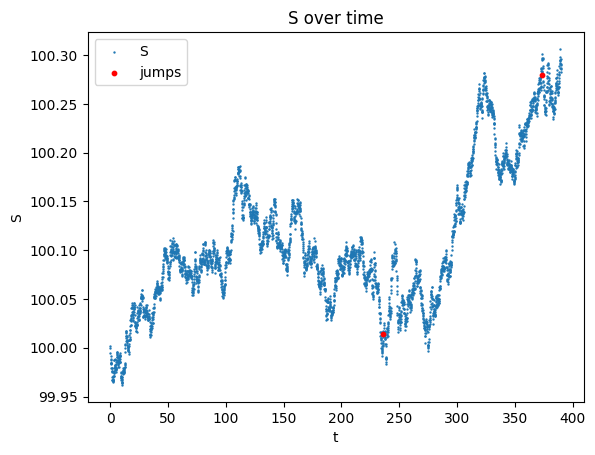

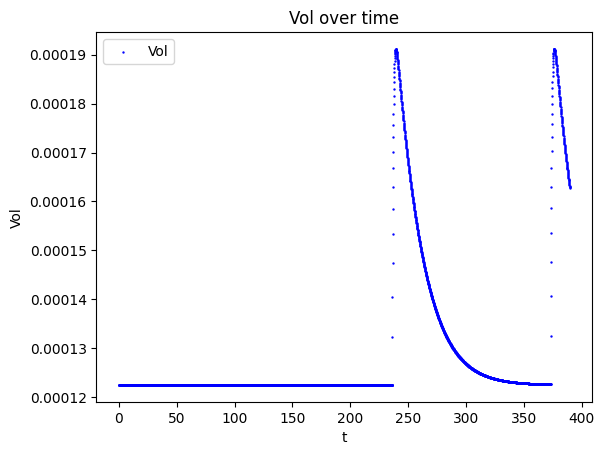

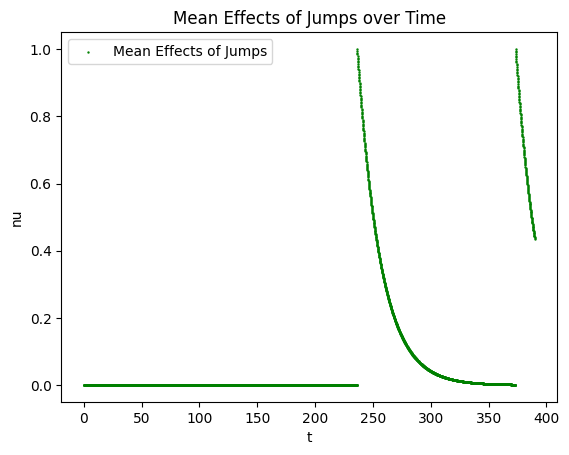

In [488]:
import matplotlib.pyplot as plt

# Run your simulation
S, nu, Y, r, t, jump_times = simulate_full_system()

# First plot: S vs t
plt.figure()
plt.scatter(t, S, s=0.5, label='S')
plt.scatter(t, jump_times, s=10, c='red', label='jumps')
plt.xlabel('t')
plt.ylabel('S')
plt.title('S over time')
plt.legend()

# Second plot: nu vs t
plt.figure()
plt.scatter(t, np.sqrt(nu), s=0.5, c='blue', label='Vol')
plt.xlabel('t')
plt.ylabel('Vol')
plt.title('Vol over time')
plt.legend()

plt.figure()
plt.scatter(t, Y, s=0.5, c='green', label='Mean Effects of Jumps')
plt.xlabel('t')
plt.ylabel('nu')
plt.title('Mean Effects of Jumps over Time')
plt.legend()

plt.show()


In [434]:
from tqdm import tqdm
final_val = np.zeros(100000)
final_var = np.zeros(100000)
for i in tqdm(range(100000)):
    j = simulate_full_system()
    final_val[i] = j[0][-1]
    final_var[i] = j[1][-1]

100%|██████████| 100000/100000 [00:25<00:00, 3885.80it/s]


Mean: 0.0003190313789624304
Std Dev: 0.024163162981879285
Min: -0.095281720294352
Max: 0.10205687112916939
Median: 6.32381670935267e-05


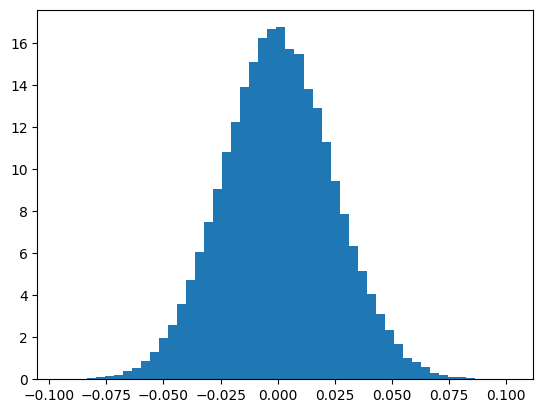

In [435]:
plt.hist(final_val/100 - 1, density = True, bins = 50)
data = final_val/100 - 1
print(f"Mean: {data.mean()}")
print(f"Std Dev: {data.std()}")
print(f"Min: {data.min()}")
print(f"Max: {data.max()}")
print(f"Median: {np.median(data)}")
plt.show()

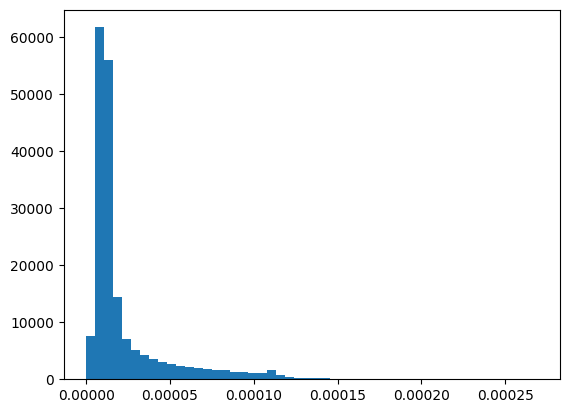

In [332]:
plt.hist(final_var, density = True, bins = 50)
plt.show()